**Input data not present in repo.** Place raw 15-minute trace CSVs at `./data/70B/online/online_{ondemand_only,shuntserve,stage_switching,request_migration,no_handle}_15min.csv` before running. These are legacy long-run traces not included in the default dataset.


In [582]:
import pandas as pd

In [583]:
ondemand_only_df        = pd.read_csv('data/70B/online/online_ondemand_only_15min.csv')
shuntserve_df           = pd.read_csv('data/70B/online/online_shuntserve_15min.csv')
stage_switching_df      = pd.read_csv('data/70B/online/online_stage_switching_15min.csv')
request_migration_df    = pd.read_csv('data/70B/online/online_request_migration_15min.csv')
no_handle_df            = pd.read_csv('data/70B/online/online_no_handle_15min.csv')

In [584]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_latency_with_moving_average(df, window=5, max_time=None, metric='p90'):
    """
    Calculate latency metric over time with moving average.
    Uses ARRIVAL TIME to determine which requests fall into each time window.

    Parameters:
    - df: DataFrame with 'ArrivalTime', 'CompletionTime', and 'Latency' columns
    - window: Window size in seconds
    - max_time: Maximum time to calculate for (in seconds). If None, use all data.
    - metric: Metric to calculate ('mean', 'median', 'p50', 'p90', 'p95', 'p99')

    Returns:
    - times: Array of time points (in seconds from start)
    - metric_values: Array of latency metric values
    """
    # Normalize time: use first arrival time as baseline (t=0)
    base_time = df['ArrivalTime'].min()
    arrival_times = df['ArrivalTime'].values - base_time
    latencies = df['Latency'].values

    # Determine time range
    if max_time is None:
        max_time_calc = int(np.ceil(arrival_times.max()))
    else:
        max_time_calc = max_time

    # Calculate latency metric for each time window
    time_points = np.arange(0, max_time_calc + 1)
    metric_values = []

    window_half_size = window // 2

    for t in time_points:
        if window_half_size == 0:
            # Only requests that arrived in this exact second [t, t+1)
            mask = (arrival_times >= t) & (arrival_times < t + 1)
        else:
            # Requests that arrived in the window [t-window_half_size, t+window_half_size+1)
            window_start = max(0, t - window_half_size)
            window_end = t + window_half_size + 1
            mask = (arrival_times >= window_start) & (arrival_times < window_end)
        
        if np.sum(mask) > 0:
            window_latencies = latencies[mask]
            
            # Calculate the requested metric
            if metric == 'mean':
                value = np.mean(window_latencies)
            elif metric in ['median', 'p50']:
                value = np.median(window_latencies)
            elif metric == 'p90':
                value = np.percentile(window_latencies, 90)
            elif metric == 'p95':
                value = np.percentile(window_latencies, 95)
            elif metric == 'p99':
                value = np.percentile(window_latencies, 99)
            else:
                raise ValueError(f"Unknown metric: {metric}. Use 'mean', 'median', 'p50', 'p90', 'p95', or 'p99'")
        else:
            value = 0  # No requests in this window
        
        metric_values.append(value)

    return time_points, np.array(metric_values)

In [585]:
def plot_latency_comparison(times_dict, latency_dict, window_size, latency_metric='p90',
                            include_ondemand=True,
                            stride=1,
                            show_average_line=False,
                            title=None,
                            figsize=(14, 6),
                            font_size_xlabel=16,
                            font_size_ylabel=16,
                            font_size_title=16,
                            font_size_legend=16,
                            font_size_ticks=16,
                            linewidth=2,
                            alpha=0.8,
                            show_grid=True):
    """
    Plot latency comparison over time for different approaches.
    
    Parameters:
    - times_dict: Dictionary with approach names as keys and time arrays as values
    - latency_dict: Dictionary with approach names as keys and latency arrays as values
    - window_size: Moving average window size used in calculation
    - latency_metric: Latency metric used ('mean', 'median', 'p50', 'p90', 'p95', 'p99')
    - include_ondemand: Whether to include 'ondemand' in the plot
    - stride: Plot every N-th data point (default=1, plot all points). Higher values reduce plot density.
    - show_average_line: If True, show horizontal line at average latency for each approach
    - title: Custom title (if None, uses default)
    - figsize: Figure size (width, height)
    - font_size_*: Font sizes for different elements
    - linewidth: Line width for plots
    - alpha: Transparency for lines
    - show_grid: Whether to show grid
    """
    plt.figure(figsize=figsize)
    
    # Define which approaches to plot
    approach_order = ['ondemand', 'shuntserve', 'concurrent_initialization', 'request_migration', 'no_handle']
    
    # Color map for each approach
    color_map = {
        'ondemand': '#808080',  # Gray
        'shuntserve': '#1f77b4',  # Blue
        'concurrent_initialization': '#ff7f0e',  # Orange
        'request_migration': '#2ca02c',  # Green
        'no_handle': '#d62728'  # Red
    }
    if include_ondemand:
        approach_order = ['ondemand'] + approach_order
    
    # Define line styles for each approach
    # line_styles = {
    #     'ondemand': '-',           # solid
    #     'shuntserve': '--',        # dashed
    #     'stage_switching': '-.',   # dash-dot
    #     'request_migration': ':',  # dotted
    #     'no_handle': (0, (3, 1, 1, 1))  # dash-dot-dot
    # }

    line_styles = {
        'ondemand': '-',          
        'shuntserve': '-',        
        'concurrent_initialization': '-',   
        'request_migration': '-', 
        'no_handle': '-'  
    }

    max_latency = 0
    min_latency = float('inf')
    
    # Plot each approach
    for approach in approach_order:
        if approach in times_dict and approach in latency_dict:
            label_map = {
                'ondemand': 'On-demand Only',
                'shuntserve': 'ShuntServe',
                'concurrent_initialization': 'Concurrent Initialization',
                'request_migration': 'Request Migration',
                'no_handle': 'No Handle'
            }
            label = label_map.get(approach, approach)
            
            # Apply stride: select every stride-th element
            times_strided = times_dict[approach][::stride]
            latency_strided = latency_dict[approach][::stride]
            
            # Get line style for this approach
            linestyle = line_styles.get(approach, '-')
            
            # Plot the time series
            # Get color for this approach
            plot_color = color_map.get(approach, None)
            
            line = plt.plot(times_strided, latency_strided, 
                    label=label, color=plot_color, linewidth=linewidth, alpha=alpha, linestyle=linestyle)
            
            # Update max/min latency
            max_latency = max(max_latency, np.max(latency_strided))
            min_latency = min(min_latency, np.min(latency_strided))

            # Add horizontal average line if requested
            if show_average_line:
                # Calculate average (excluding zero values which indicate no data)
                latency_nonzero = latency_dict[approach][latency_dict[approach] > 0]
                if len(latency_nonzero) > 0:
                    avg_latency = np.mean(latency_nonzero)
                    color = line[0].get_color()
                    plt.axhline(y=avg_latency, color=plot_color, linestyle='--', 
                               linewidth=3, alpha=0.6, dashes=(5, 7))
    
    if show_average_line:
        plt.plot([], [], color='black', linestyle='--', linewidth=2.5, alpha=0.6, label='Avg Latency')

    plt.ylim(min_latency * 0.95, max_latency * 1.05)
    
    # Add labels and title
    plt.xlabel('Time (seconds)', fontsize=font_size_xlabel)
    plt.ylabel(f'Latency - {latency_metric.upper()} (seconds)', fontsize=font_size_ylabel)
    
    # if title is None:
    #     title = f'LLM Serving Latency Comparison: Spot Interruption Handling Strategies\n(Moving Average Window: {window_size}s, Metric: {latency_metric.upper()})'
    plt.title(title, fontsize=font_size_title, fontweight='bold')
    
    # Set tick font sizes
    plt.xticks(fontsize=font_size_ticks)
    plt.yticks(fontsize=font_size_ticks)
    
    
    # Add grid if requested
    if show_grid:
        plt.grid(True, alpha=0.3, linestyle='--')
    
    # Adjust layout
    plt.tight_layout()
    
    # Display the plot
    
    # Display the plot
    plt.savefig("preemption_tolerance_online_serving.pdf", dpi=300, bbox_inches='tight')
    plt.show()

Latency Metric: P90
Window size: 720 seconds
Duration: 3000 seconds
On-demand Only - Duration: 3000 seconds, Peak Latency: 562.37s
Shuntserve - Duration: 3000 seconds, Peak Latency: 681.12s
Stage Switching - Duration: 3000 seconds, Peak Latency: 932.76s
Request Migration - Duration: 3000 seconds, Peak Latency: 962.61s
No Handle - Duration: 3000 seconds, Peak Latency: 1350.46s


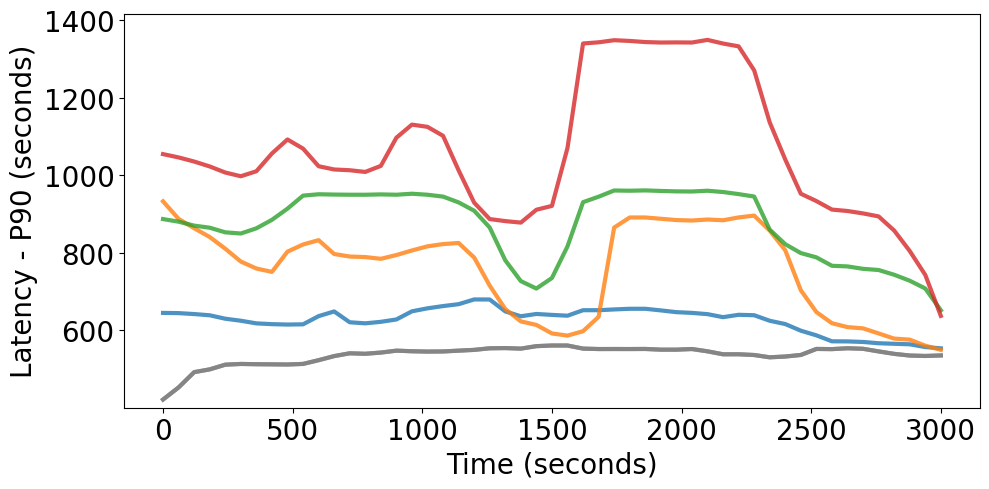

In [586]:
# Set window size for moving average (0 = no averaging, just per second)
window_size = 720
duration = 3000
latency_metric = 'p90'  # Options: 'mean', 'median', 'p50', 'p90', 'p95', 'p99'

# Calculate latency metric over time for each approach 
ondemand_times, ondemand_latency = calculate_latency_with_moving_average(ondemand_only_df, window=window_size, max_time=duration, metric=latency_metric)
shuntserve_times, shuntserve_latency = calculate_latency_with_moving_average(shuntserve_df, window=window_size, max_time=duration, metric=latency_metric)
stage_switching_times, stage_switching_latency = calculate_latency_with_moving_average(stage_switching_df, window=window_size, max_time=duration, metric=latency_metric)
request_migration_times, request_migration_latency = calculate_latency_with_moving_average(request_migration_df, window=window_size, max_time=duration, metric=latency_metric)
no_handle_times, no_handle_latency = calculate_latency_with_moving_average(no_handle_df, window=window_size, max_time=duration, metric=latency_metric)

print(f"Latency Metric: {latency_metric.upper()}")
print(f"Window size: {window_size} seconds")
print(f"Duration: {duration} seconds")

# For peak latency, ignore zero values (no data)
print(f"On-demand Only - Duration: {ondemand_times[-1]} seconds, Peak Latency: {ondemand_latency[ondemand_latency > 0].max():.2f}s")
print(f"Shuntserve - Duration: {shuntserve_times[-1]} seconds, Peak Latency: {shuntserve_latency[shuntserve_latency > 0].max():.2f}s")
print(f"Stage Switching - Duration: {stage_switching_times[-1]} seconds, Peak Latency: {stage_switching_latency[stage_switching_latency > 0].max():.2f}s")
print(f"Request Migration - Duration: {request_migration_times[-1]} seconds, Peak Latency: {request_migration_latency[request_migration_latency > 0].max():.2f}s")
print(f"No Handle - Duration: {no_handle_times[-1]} seconds, Peak Latency: {no_handle_latency[no_handle_latency > 0].max():.2f}s")

# Create latency comparison plot using the function
times_dict = {
    'ondemand': ondemand_times,
    'shuntserve': shuntserve_times,
    'concurrent_initialization': stage_switching_times,
    'request_migration': request_migration_times,
    'no_handle': no_handle_times
}

latency_dict = {
    'ondemand': ondemand_latency,
    'shuntserve': shuntserve_latency,
    'concurrent_initialization': stage_switching_latency,
    'request_migration': request_migration_latency,
    'no_handle': no_handle_latency
}

plot_latency_comparison(
    times_dict=times_dict,
    latency_dict=latency_dict,
    window_size=window_size,
    show_average_line=False,
    latency_metric=latency_metric,
    include_ondemand=True,
    font_size_xlabel=20,
    font_size_ylabel=20,
    font_size_title=20,
    font_size_legend=20,
    font_size_ticks=20,
    linewidth=3,
    show_grid=False,
    figsize=(10, 5),
    stride=60
)

In [587]:
# Calculate latency statistics including percentiles
def calculate_latency_statistics(df, max_time=None):
    """
    Calculate comprehensive latency statistics including percentiles.
    
    Parameters:
    - df: DataFrame with 'ArrivalTime', 'CompletionTime', and 'Latency' columns
    - max_time: Maximum time in seconds from start. If None, use all data.
    
    Returns:
    - dict with keys:
        - 'mean': Average latency
        - 'p05', 'p10', 'p25', 'p50' (median), 'p75', 'p90', 'p95': Percentile values
        - 'total_duration': Total duration in seconds
        - 'total_requests': Total number of requests
    """
    base_time = df['ArrivalTime'].min()
    
    if max_time is None:
        # Use all data
        total_duration = df['CompletionTime'].max() - base_time
        filtered_df = df
    else:
        # Only count requests that arrived within max_time
        cutoff_time = base_time + max_time
        filtered_df = df[df['ArrivalTime'] <= cutoff_time]
        total_duration = max_time
    
    latencies = filtered_df['Latency'].values
    
    stats = {
        'mean': np.mean(latencies),
        'p05': np.percentile(latencies, 5),
        'p10': np.percentile(latencies, 10),
        'p25': np.percentile(latencies, 25),
        'p50': np.percentile(latencies, 50),  # median
        'p75': np.percentile(latencies, 75),
        'p90': np.percentile(latencies, 90),
        'p95': np.percentile(latencies, 95),
        'total_duration': total_duration,
        'total_requests': len(filtered_df)
    }
    
    return stats

In [588]:
# Calculate latency statistics for each approach
ondemand_stats = calculate_latency_statistics(ondemand_only_df, max_time=duration)
shuntserve_stats = calculate_latency_statistics(shuntserve_df, max_time=duration)
stage_switching_stats = calculate_latency_statistics(stage_switching_df, max_time=duration)
request_migration_stats = calculate_latency_statistics(request_migration_df, max_time=duration)
no_handle_stats = calculate_latency_statistics(no_handle_df, max_time=duration)

print(f"Latency Statistics (all values in seconds)")
print("=" * 80)
print(f"On-demand Only:")
print(f"  Mean: {ondemand_stats['mean']:.2f}s, Median (P50): {ondemand_stats['p50']:.2f}s")
print(f"  Whiskers [P05-P95]: [{ondemand_stats['p05']:.2f}s, {ondemand_stats['p95']:.2f}s]")
print(f"  Box [P25-P75]: [{ondemand_stats['p25']:.2f}s, {ondemand_stats['p75']:.2f}s]")
print(f"  ({ondemand_stats['total_requests']} requests / {ondemand_stats['total_duration']:.2f}s)")

print(f"\nShuntServe:")
print(f"  Mean: {shuntserve_stats['mean']:.2f}s, Median (P50): {shuntserve_stats['p50']:.2f}s")
print(f"  Whiskers [P05-P95]: [{shuntserve_stats['p05']:.2f}s, {shuntserve_stats['p95']:.2f}s]")
print(f"  Box [P25-P75]: [{shuntserve_stats['p25']:.2f}s, {shuntserve_stats['p75']:.2f}s]")
print(f"  ({shuntserve_stats['total_requests']} requests / {shuntserve_stats['total_duration']:.2f}s)")

print(f"\nStage Switching:")
print(f"  Mean: {stage_switching_stats['mean']:.2f}s, Median (P50): {stage_switching_stats['p50']:.2f}s")
print(f"  Whiskers [P05-P95]: [{stage_switching_stats['p05']:.2f}s, {stage_switching_stats['p95']:.2f}s]")
print(f"  Box [P25-P75]: [{stage_switching_stats['p25']:.2f}s, {stage_switching_stats['p75']:.2f}s]")
print(f"  ({stage_switching_stats['total_requests']} requests / {stage_switching_stats['total_duration']:.2f}s)")

print(f"\nRequest Migration:")
print(f"  Mean: {request_migration_stats['mean']:.2f}s, Median (P50): {request_migration_stats['p50']:.2f}s")
print(f"  Whiskers [P05-P95]: [{request_migration_stats['p05']:.2f}s, {request_migration_stats['p95']:.2f}s]")
print(f"  Box [P25-P75]: [{request_migration_stats['p25']:.2f}s, {request_migration_stats['p75']:.2f}s]")
print(f"  ({request_migration_stats['total_requests']} requests / {request_migration_stats['total_duration']:.2f}s)")

print(f"\nNo Handle:")
print(f"  Mean: {no_handle_stats['mean']:.2f}s, Median (P50): {no_handle_stats['p50']:.2f}s")
print(f"  Whiskers [P05-P95]: [{no_handle_stats['p05']:.2f}s, {no_handle_stats['p95']:.2f}s]")
print(f"  Box [P25-P75]: [{no_handle_stats['p25']:.2f}s, {no_handle_stats['p75']:.2f}s]")
print(f"  ({no_handle_stats['total_requests']} requests / {no_handle_stats['total_duration']:.2f}s)")

Latency Statistics (all values in seconds)
On-demand Only:
  Mean: 299.42s, Median (P50): 286.71s
  Whiskers [P05-P95]: [42.39s, 578.82s]
  Box [P25-P75]: [111.77s, 482.72s]
  (3219 requests / 3000.00s)

ShuntServe:
  Mean: 340.96s, Median (P50): 313.82s
  Whiskers [P05-P95]: [43.50s, 683.59s]
  Box [P25-P75]: [121.77s, 540.31s]
  (3219 requests / 3000.00s)

Stage Switching:
  Mean: 377.54s, Median (P50): 347.02s
  Whiskers [P05-P95]: [47.34s, 927.95s]
  Box [P25-P75]: [123.56s, 541.36s]
  (3219 requests / 3000.00s)

Request Migration:
  Mean: 450.97s, Median (P50): 410.30s
  Whiskers [P05-P95]: [45.34s, 973.45s]
  Box [P25-P75]: [160.02s, 696.47s]
  (3219 requests / 3000.00s)

No Handle:
  Mean: 513.24s, Median (P50): 463.97s
  Whiskers [P05-P95]: [50.17s, 1280.38s]
  Box [P25-P75]: [160.80s, 728.71s]
  (3219 requests / 3000.00s)


In [589]:
g6_12xlarge_ondemand_price_per_hour = 4.6016
g5_12xlarge_ondemand_price_per_hour = 5.6720
g6e_xlarge_ondemand_price_per_hour = 1.8610

g6_12xlarge_spot_price_per_hour = 1.9445
g5_12xlarge_spot_price_per_hour = 2.2915
g6e_xlarge_spot_price_per_hour = 0.7040

In [590]:
ondemand_only_ondemand_time_g6_12xlarge_min = 150
ondemand_only_ondemand_time_g5_12xlarge_min = 100
ondemand_only_ondemand_time_g6e_xlarge_min = 200
ondemand_only_spot_time_g6_12xlarge_min = 0
ondemand_only_spot_time_g5_12xlarge_min = 0
ondemand_only_spot_time_g6e_xlarge_min = 0

g6_12xlarge_ondemand_time_with_mixed = 25
g5_12xlarge_ondemand_time_with_mixed = 60
g6e_xlarge_ondemand_time_with_mixed = 80
g6_12xlarge_spot_time_with_mixed = 125
g5_12xlarge_spot_time_with_mixed = 40
g6e_xlarge_spot_time_with_mixed = 120

shuntserve_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
shuntserve_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
shuntserve_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
shuntserve_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
shuntserve_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
shuntserve_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

stage_switching_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
stage_switching_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
stage_switching_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
stage_switching_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
stage_switching_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
stage_switching_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

request_migration_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
request_migration_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
request_migration_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
request_migration_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
request_migration_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
request_migration_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

no_handle_ondemand_time_g6_12xlarge_min = g6_12xlarge_ondemand_time_with_mixed
no_handle_ondemand_time_g5_12xlarge_min = g5_12xlarge_ondemand_time_with_mixed
no_handle_ondemand_time_g6e_xlarge_min = g6e_xlarge_ondemand_time_with_mixed
no_handle_spot_time_g6_12xlarge_min = g6_12xlarge_spot_time_with_mixed
no_handle_spot_time_g5_12xlarge_min = g5_12xlarge_spot_time_with_mixed
no_handle_spot_time_g6e_xlarge_min = g6e_xlarge_spot_time_with_mixed

In [591]:
ondemand_only_price = (
    ondemand_only_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    ondemand_only_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    ondemand_only_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    ondemand_only_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    ondemand_only_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    ondemand_only_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

shuntserve_price = (
    shuntserve_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    shuntserve_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    shuntserve_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    shuntserve_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

stage_switching_price = (
    stage_switching_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    stage_switching_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    stage_switching_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    stage_switching_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

request_migration_price = (
    request_migration_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    request_migration_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    request_migration_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    request_migration_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    request_migration_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    request_migration_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

no_handle_price = (
    no_handle_ondemand_time_g6_12xlarge_min * g6_12xlarge_ondemand_price_per_hour + 
    no_handle_ondemand_time_g5_12xlarge_min * g5_12xlarge_ondemand_price_per_hour + 
    no_handle_ondemand_time_g6e_xlarge_min * g6e_xlarge_ondemand_price_per_hour + 
    no_handle_spot_time_g6_12xlarge_min * g6_12xlarge_spot_price_per_hour + 
    no_handle_spot_time_g5_12xlarge_min * g5_12xlarge_spot_price_per_hour + 
    no_handle_spot_time_g6e_xlarge_min * g6e_xlarge_spot_price_per_hour
) / 60

print(f"Ondemand Only Total Price: ${ondemand_only_price:.2f}")
print(f"ShuntServe Total Price: ${shuntserve_price:.2f}")
print(f"Stage Switching Total Price: ${stage_switching_price:.2f}")
print(f"Request Migration Total Price: ${request_migration_price:.2f}")
print(f"No Handle Total Price: ${no_handle_price:.2f}")

Ondemand Only Total Price: $27.16
ShuntServe Total Price: $17.06
Stage Switching Total Price: $17.06
Request Migration Total Price: $17.06
No Handle Total Price: $17.06


In [592]:
# ShuntServe and Stage Switching overhead (overlapped instance time in seconds)
# These values need to be adjusted based on actual online data
shuntserve_spot_g6_12xlarge_overlapped_seconds     = 96 * 1
shuntserve_spot_g5_12xlarge_overlapped_seconds     = 98 * 2
shuntserve_spot_g6e_xlarge_overlapped_seconds      = 98 * 2 + 96 * 2
shuntserve_ondemand_g6_12xlarge_overlapped_seconds = 96 * 2
shuntserve_ondemand_g5_12xlarge_overlapped_seconds = 98 + 98
shuntserve_ondemand_g6e_xlarge_overlapped_seconds  = 96 * 2 + 98 * 2

stage_switching_spot_g6_12xlarge_overlapped_seconds     = 96 * 1
stage_switching_spot_g5_12xlarge_overlapped_seconds     = 98 * 2
stage_switching_spot_g6e_xlarge_overlapped_seconds      = 98 * 2 + 96 * 2
stage_switching_ondemand_g6_12xlarge_overlapped_seconds = 96 * 2
stage_switching_ondemand_g5_12xlarge_overlapped_seconds = 98 + 98
stage_switching_ondemand_g6e_xlarge_overlapped_seconds  = 96 * 2 + 98 * 2

shuntserve_overhead_price = (
    shuntserve_spot_g6_12xlarge_overlapped_seconds * g6_12xlarge_spot_price_per_hour + 
    shuntserve_spot_g5_12xlarge_overlapped_seconds * g5_12xlarge_spot_price_per_hour + 
    shuntserve_spot_g6e_xlarge_overlapped_seconds * g6e_xlarge_spot_price_per_hour + 
    shuntserve_ondemand_g6_12xlarge_overlapped_seconds * g6_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_g5_12xlarge_overlapped_seconds * g5_12xlarge_ondemand_price_per_hour + 
    shuntserve_ondemand_g6e_xlarge_overlapped_seconds * g6e_xlarge_ondemand_price_per_hour
) / 3600

stage_switching_overhead_price = (
    stage_switching_spot_g6_12xlarge_overlapped_seconds * g6_12xlarge_spot_price_per_hour + 
    stage_switching_spot_g5_12xlarge_overlapped_seconds * g5_12xlarge_spot_price_per_hour + 
    stage_switching_spot_g6e_xlarge_overlapped_seconds * g6e_xlarge_spot_price_per_hour + 
    stage_switching_ondemand_g6_12xlarge_overlapped_seconds * g6_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_g5_12xlarge_overlapped_seconds * g5_12xlarge_ondemand_price_per_hour + 
    stage_switching_ondemand_g6e_xlarge_overlapped_seconds * g6e_xlarge_ondemand_price_per_hour
) / 3600

print(f"ShuntServe Overhead Price: ${shuntserve_overhead_price:.2f}")
print(f"Stage Switching Overhead Price: ${stage_switching_overhead_price:.2f}")

shuntserve_total_price = shuntserve_price + shuntserve_overhead_price
stage_switching_total_price = stage_switching_price + stage_switching_overhead_price

print(f"\nFinal Costs:")
print(f"Ondemand Only Total Price: ${ondemand_only_price:.2f}")
print(f"ShuntServe Total Price: ${shuntserve_total_price:.2f}")
print(f"Stage Switching Total Price: ${stage_switching_total_price:.2f}")
print(f"Request Migration Total Price: ${request_migration_price:.2f}")
print(f"No Handle Total Price: ${no_handle_price:.2f}")

ShuntServe Overhead Price: $1.01
Stage Switching Overhead Price: $1.01

Final Costs:
Ondemand Only Total Price: $27.16
ShuntServe Total Price: $18.06
Stage Switching Total Price: $18.06
Request Migration Total Price: $17.06
No Handle Total Price: $17.06


In [593]:
# Calculate Latency × Cost (lower is better - both low latency and low cost are desirable)
# Using mean latency for the calculation
ondemand_only_latency_cost = ondemand_stats['p90'] * ondemand_only_price
shuntserve_latency_cost = shuntserve_stats['p90'] * shuntserve_total_price
stage_switching_latency_cost = stage_switching_stats['p90'] * stage_switching_total_price
request_migration_latency_cost = request_migration_stats['p90'] * request_migration_price
no_handle_latency_cost = no_handle_stats['p90'] * no_handle_price

print(f"Latency × Cost (sec·$, lower is better):")
print(f"On-demand Only: {ondemand_only_latency_cost:.2f}")
print(f"ShuntServe: {shuntserve_latency_cost:.2f}")
print(f"Stage Switching: {stage_switching_latency_cost:.2f}")
print(f"Request Migration: {request_migration_latency_cost:.2f}")
print(f"No Handle: {no_handle_latency_cost:.2f}")

Latency × Cost (sec·$, lower is better):
On-demand Only: 14743.76
ShuntServe: 11424.32
Stage Switching: 13744.41
Request Migration: 15346.84
No Handle: 18311.05


In [594]:
def plot_latency_distribution(latency_stats_list, costs, 
                                   approaches=['On-demand\nOnly', 'Stage\nSwitching', 'Stop and\nStart'],
                                   title='Latency Distribution and Cost',
                                   fontsize=16,
                                   figsize=(10, 6)):
    """
    Plot latency distribution using box plot style with cost overlay.
    
    Parameters:
    - latency_stats_list: List of dicts with keys 'mean', 'p05', 'p10', 'p25', 'p50', 'p75', 'p90', 'p95'
    - costs: List of cost values for each approach ($)
    - approaches: List of approach names
    - title: Plot title
    - fontsize: Unified font size for all text elements
    - figsize: Figure size (width, height)
    """
    import numpy as np
    
    fig, ax1 = plt.subplots(figsize=figsize)
    
    colors = ['#808080', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Gray for On-demand, Blue: ShuntServe, Orange: Concurrent, Green: Request, Red: No Handle
    
    n_approaches = len(approaches)
    x_positions = np.arange(n_approaches)
    box_width = 0.8
    
    # Draw box plots for latency distribution
    for i, (approach, stats, color) in enumerate(zip(approaches, latency_stats_list, colors)):
        x = x_positions[i]
        
        # Box (P25 to P75)
        box_bottom = stats['p25']
        box_height = stats['p75'] - stats['p25']
        rect = plt.Rectangle((x - box_width/2, box_bottom), box_width, box_height,
                            facecolor=color, edgecolor='black', linewidth=1.5, 
                            alpha=0.7, zorder=2)
        ax1.add_patch(rect)
        
        # Whiskers (P10 to P90)
        ax1.plot([x, x], [stats['p10'], stats['p25']], 
                color='black', linewidth=2, zorder=3)
        ax1.plot([x, x], [stats['p75'], stats['p90']], 
                color='black', linewidth=2, zorder=3)
        
        # Caps at whisker ends
        cap_width = box_width * 0.3
        ax1.plot([x - cap_width/2, x + cap_width/2], [stats['p10'], stats['p10']], 
                color='black', linewidth=2, zorder=3)
        ax1.plot([x - cap_width/2, x + cap_width/2], [stats['p90'], stats['p90']], 
                color='black', linewidth=2, zorder=3)
        
        # Median line (P50) - RED solid
        ax1.plot([x - box_width/2, x + box_width/2], [stats['p50'], stats['p50']], 
                color='red', linewidth=2.5, zorder=5)
    
    # Set x-axis
    ax1.set_xticks(x_positions)
    ax1.set_xticklabels(approaches, fontsize=fontsize, rotation=15, ha='center')
    ax1.set_xlim(-0.5, n_approaches - 0.5)
    
    # Find y-axis limits
    all_p10 = [s['p10'] for s in latency_stats_list]
    all_p90 = [s['p90'] for s in latency_stats_list]
    y_min = min(all_p10) * 0.8
    y_max = max(all_p90) * 1.2
    ax1.set_ylim(y_min, y_max)
    
    ax1.set_ylabel('Latency (seconds)', fontsize=fontsize)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax1.tick_params(axis='y', labelsize=fontsize)
    
    # Add cost overlay with secondary y-axis
    ax1_twin = ax1.twinx()
    
    # Plot markers at actual cost values
    min_cost = min(costs)
    max_cost = max(costs)
    cost_range = max_cost - min_cost
    
    for i, (approach, cost, color) in enumerate(zip(approaches, costs, colors)):
        ax1_twin.plot(i, cost, marker='o', markersize=12, color=color, linestyle='',
                      markeredgecolor='black', markeredgewidth=2, zorder=6)
        # Add cost value labels with fixed offset
        ax1_twin.text(i, cost - cost_range * 0.12, f'${cost:.2f}', 
                      ha='center', va='top', fontsize=fontsize)
    
    ax1_twin.set_ylabel('Cost ($)', fontsize=fontsize)
    ax1_twin.set_ylim(min_cost * 0.5, max_cost * 1.35)
    ax1_twin.tick_params(axis='y', labelsize=fontsize)
    
    # Title with box plot explanation
    full_title = title
    ax1.set_title(full_title, fontsize=fontsize)
    
    plt.tight_layout()
    plt.savefig("latency_cost_comparison_online.pdf", dpi=300, bbox_inches='tight')
    plt.show()


def plot_latency_cost_product(latency_cost_products, 
                               approaches=['On-demand\nOnly', 'Stage\nSwitching', 'Stop and\nStart'],
                               title='Cost-Latency Trade-off (Lower is Better)',
                               fontsize=16,
                               figsize=(10, 6)):
    """
    Plot latency × cost product bar chart.
    
    Parameters:
    - latency_cost_products: List of latency × cost values (sec·$, lower is better)
    - approaches: List of approach names
    - title: Plot title
    - fontsize: Unified font size for all text elements
    - figsize: Figure size (width, height)
    """
    fig, ax = plt.subplots(figsize=figsize)
    
    colors = ['#808080', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Gray for On-demand, Blue: ShuntServe, Orange: Concurrent, Green: Request, Red: No Handle
    
    # Create bars
    bars = ax.bar(approaches, latency_cost_products, width=0.8, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    
    # Add value labels on bars
    for bar, lcp in zip(bars, latency_cost_products):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                 f'{lcp:.2f}',
                 ha='center', va='top', fontsize=fontsize)
    
    ax.set_ylabel('P90 Latency × Cost (sec·$)', fontsize=fontsize)
    ax.set_ylim(0, max(latency_cost_products) * 1.35)
    ax.grid(True, axis='y', alpha=0.3, linestyle='--')
    ax.set_title(title, fontsize=fontsize)
    ax.tick_params(axis='both', labelsize=fontsize)
    plt.xticks(rotation=15, ha='center')
    
    plt.tight_layout()
    plt.savefig("cost_efficiency_online_serving.pdf", dpi=300, bbox_inches='tight')
    plt.show()


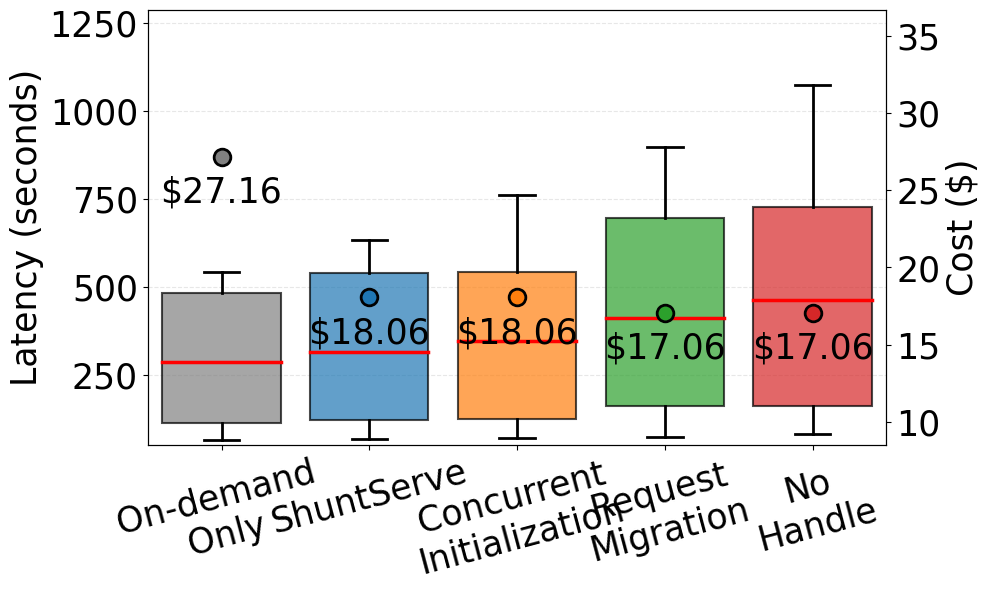

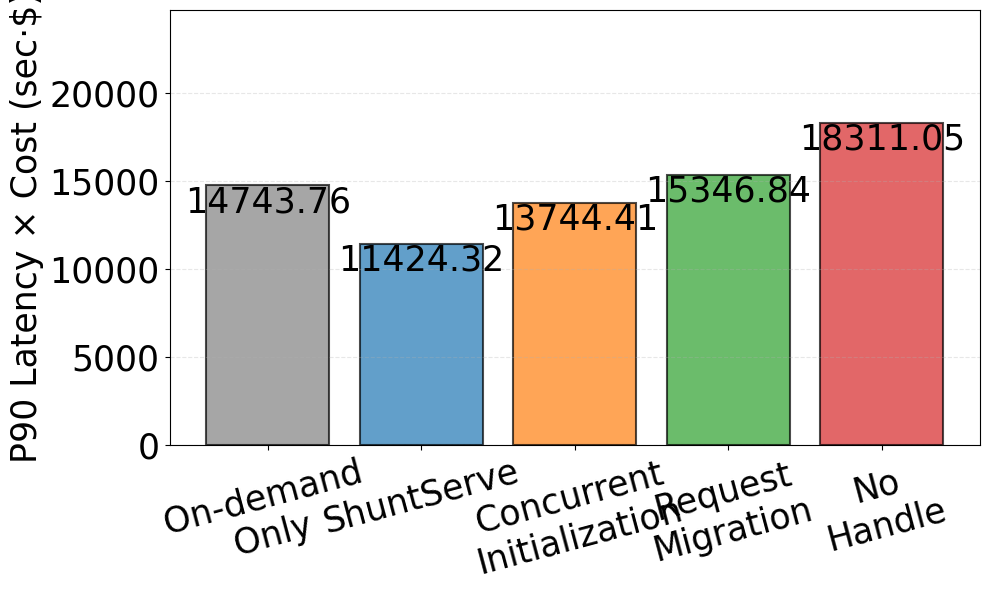

In [595]:
# Plot latency distribution and cost-latency trade-off
latency_stats_list = [ondemand_stats, shuntserve_stats, stage_switching_stats, request_migration_stats, no_handle_stats]
costs_list = [ondemand_only_price, shuntserve_total_price, stage_switching_total_price, request_migration_price, no_handle_price]
latency_cost_list = [ondemand_only_latency_cost, shuntserve_latency_cost, stage_switching_latency_cost, request_migration_latency_cost, no_handle_latency_cost]
approaches_list = ['On-demand\nOnly', 'ShuntServe', 'Concurrent\nInitialization', 'Request\nMigration', 'No\nHandle']

plot_latency_distribution(
    latency_stats_list=latency_stats_list,
    costs=costs_list,
    approaches=approaches_list,
    title=None,
    fontsize=25,
    figsize=(10, 6)
)

plot_latency_cost_product(
    latency_cost_products=latency_cost_list,
    approaches=approaches_list,
    title=None,
    fontsize=25,
    figsize=(10, 6)
)